In [1]:
!pip install HawkesPyLib

# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import pandas as pd
import scipy.stats as stats
from numpy.linalg import inv

from HawkesPyLib.simulation import ExpHawkesProcessSimulation

# 1. Properties of Hawkes MLE estimates 

## Simulation of one dimensional Hawkes Process

In [2]:
# Parameters
mu = 1.2      # baseline intensity
alpha = 0.6   # excitation parameter
beta = 0.8    # decay parameter
T = 100       # simulation horizon

theta = 1 / beta
eta = alpha / beta

In [3]:
print(eta)

0.7499999999999999


In [4]:
hawkes = ExpHawkesProcessSimulation(mu=mu, eta=eta, theta=theta)

In [5]:
events = hawkes.simulate(T, seed=42)

In [6]:
print("Number of events:", len(events))
print("First events:", events[:10])

Number of events: 361
First events: [0.39105674 2.06334643 2.52974061 2.60279308 3.30653735 5.2928917
 5.40573646 5.48259425 5.71872131 5.81952488]


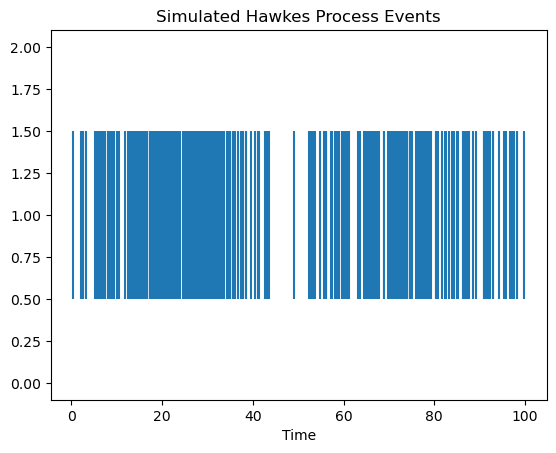

In [7]:
# Plot event timeline
plt.figure()
plt.eventplot(events, orientation="horizontal")
plt.title("Simulated Hawkes Process Events")
plt.xlabel("Time")
plt.show()

In [8]:
def hawkes_intensity(t, events, mu, alpha, beta):
    past_events = events[events < t]
    return mu + np.sum(alpha * np.exp(-beta * (t - past_events)))

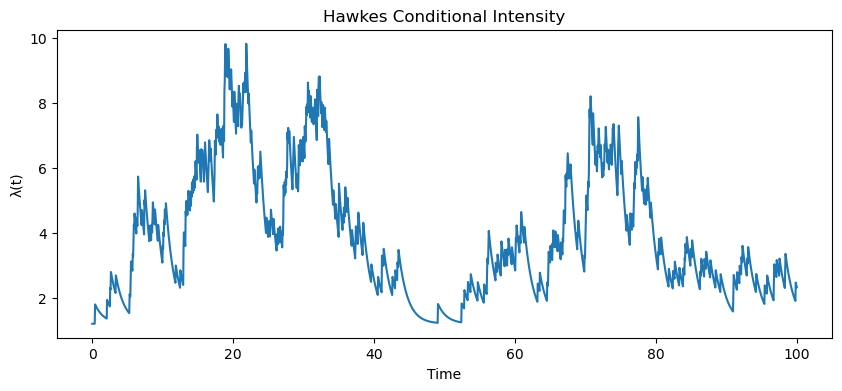

In [9]:
times = np.linspace(0, T, 2000)
intensity = [hawkes_intensity(t, events, mu, alpha, beta) for t in times]

plt.figure(figsize=(10,4))
plt.plot(times, intensity)
#plt.vlines(events, ymin=0, ymax=max(intensity), linestyles="dashed")
plt.xlabel("Time")
plt.ylabel("λ(t)")
plt.title("Hawkes Conditional Intensity")
plt.show()

## MLE estimator

In [10]:
def hawkes_loglik(params, events, T):
    mu, alpha, beta = params
    
    if mu <= 0 or alpha <= 0 or beta <= 0:
        return np.inf
    
    n = len(events)
    
    intensity_sum = 0
    
    for i in range(n):
        ti = events[i]
        past = events[:i]
        
        excitation = np.sum(alpha * np.exp(-beta * (ti - past)))
        lam = mu + excitation
        
        intensity_sum += np.log(lam)
    
    compensator = mu*T + (alpha/beta)*np.sum(1 - np.exp(-beta*(T - events)))
    
    loglik = intensity_sum - compensator
    
    return -loglik

In [11]:
def estimate_hawkes(events, T):

    init = np.array([0.1, 0.2, 1.0])

    bounds = [
        (1e-6, None),  # mu
        (1e-6, None),  # alpha
        (1e-6, None)   # beta
    ]

    result = minimize(
        hawkes_loglik,
        init,
        args=(events, T),
        bounds=bounds,
        method="L-BFGS-B"
    )

    return result.x

In [12]:
mu_hat, alpha_hat, beta_hat = estimate_hawkes(events, T)

In [13]:
print(mu_hat, alpha_hat, beta_hat)

0.6750796737948342 0.5311254529122718 0.6490187697961705


In [14]:
def simulate_hawkes(mu, alpha, beta, T, seed=0):

    theta = 1 / beta
    eta = alpha / beta

    sim = ExpHawkesProcessSimulation(mu=mu, eta=eta, theta=theta)

    events = sim.simulate(T, seed=seed)

    return events

## Consistence of MLE estimator 

In [16]:
T_values = [50,100,200,400,800]

results = []

for T in T_values:

    events = simulate_hawkes(mu,alpha,beta,T)

    mu_hat,alpha_hat,beta_hat = estimate_hawkes(events,T)

    results.append([T,mu_hat,alpha_hat,beta_hat])

df = pd.DataFrame(
    results,
    columns=["T","mu_hat","alpha_hat","beta_hat"]
)

print(df)

     T    mu_hat  alpha_hat  beta_hat
0   50  0.947278   1.060316  1.427493
1  100  1.604711   0.468528  0.743470
2  200  1.145326   0.551523  0.729070
3  400  1.069345   0.597314  0.746467
4  800  1.191797   0.596619  0.802463


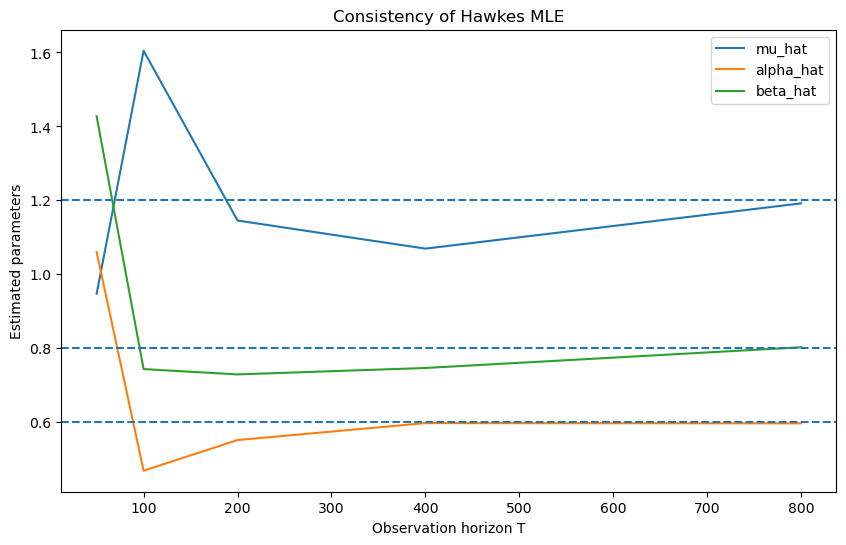

In [17]:
plt.figure(figsize=(10,6))

plt.plot(df["T"],df["mu_hat"],label="mu_hat")
plt.axhline(mu,linestyle="--")

plt.plot(df["T"],df["alpha_hat"],label="alpha_hat")
plt.axhline(alpha,linestyle="--")

plt.plot(df["T"],df["beta_hat"],label="beta_hat")
plt.axhline(beta,linestyle="--")

plt.xlabel("Observation horizon T")
plt.ylabel("Estimated parameters")

plt.legend()
plt.title("Consistency of Hawkes MLE")

plt.show()

## Asymptotically normality of the Estimator

In [32]:
theta_true = np.array([mu,alpha,beta])

T = 800
n_sim = 400

Z = []

for s in range(n_sim):

    events = simulate_hawkes(mu,alpha,beta,T,seed=s)

    theta_hat = estimate_hawkes(events,T)

    Z.append(np.sqrt(T)*(theta_hat-theta_true))

Z = np.array(Z)

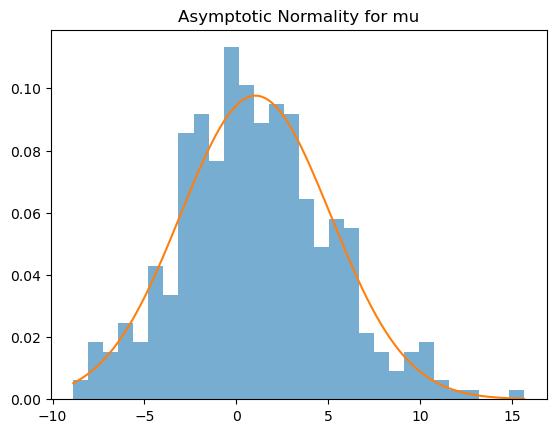

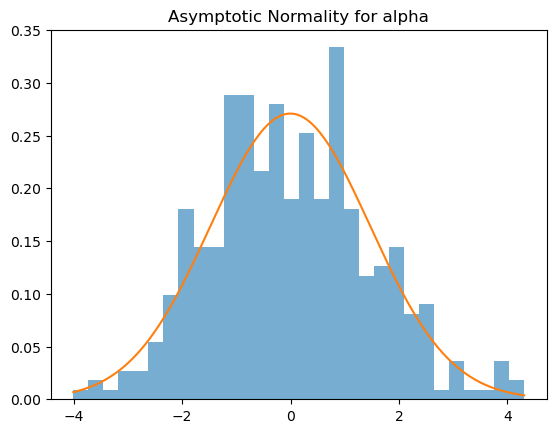

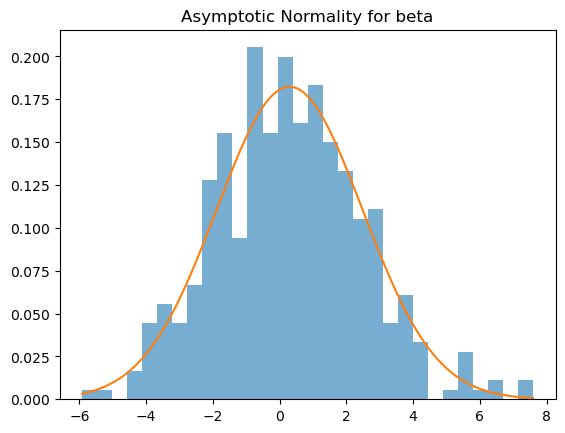

In [33]:
params = ["mu","alpha","beta"]

for i in range(3):

    plt.figure()

    plt.hist(Z[:,i], bins=30, density=True, alpha=0.6)

    x = np.linspace(min(Z[:,i]),max(Z[:,i]),200)

    plt.plot(x, stats.norm.pdf(x,np.mean(Z[:,i]),np.std(Z[:,i])))

    plt.title(f"Asymptotic Normality for {params[i]}")
    
    plt.show()

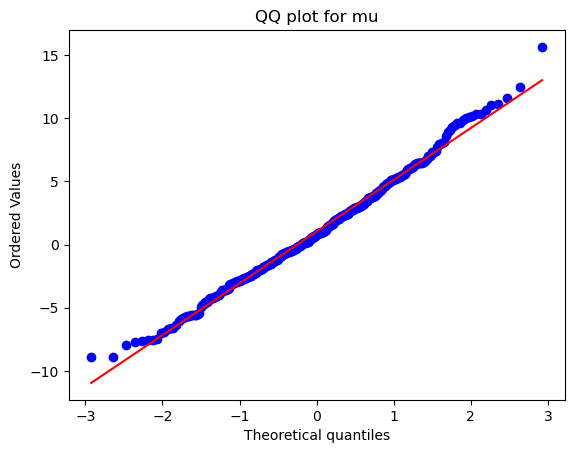

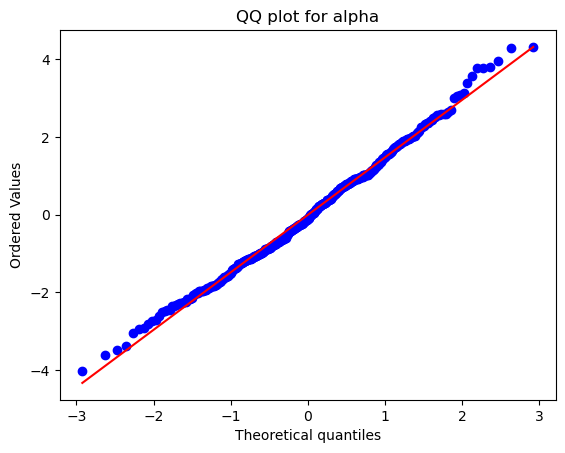

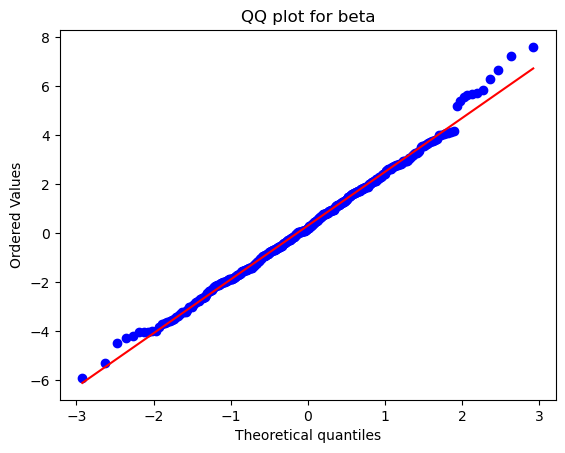

In [34]:
for i in range(3):

    stats.probplot(Z[:,i], dist="norm", plot=plt)

    plt.title(f"QQ plot for {params[i]}")
    
    plt.show()

## Asymptotically Efficience

In [20]:
def numerical_hessian(f, x, eps=1e-4, *args):

    n = len(x)
    H = np.zeros((n,n))

    for i in range(n):
        for j in range(n):

            x1 = x.copy(); x1[i]+=eps; x1[j]+=eps
            x2 = x.copy(); x2[i]+=eps; x2[j]-=eps
            x3 = x.copy(); x3[i]-=eps; x3[j]+=eps
            x4 = x.copy(); x4[i]-=eps; x4[j]-=eps

            H[i,j] = (
                f(x1,*args) - f(x2,*args)
                - f(x3,*args) + f(x4,*args)
            )/(4*eps**2)

    return H

In [22]:
theta_true = np.array([mu,alpha,beta])

In [37]:
T = 800
n_sim = 200

theta_hat_list = []

for s in range(n_sim):

    events = simulate_hawkes(mu,alpha,beta,T,seed=s)

    theta_hat = estimate_hawkes(events,T)

    theta_hat_list.append(theta_hat)

theta_hat_list = np.array(theta_hat_list)

In [38]:
emp_cov = np.cov(theta_hat_list.T)

print("Empirical covariance:")
print(emp_cov)

Empirical covariance:
[[0.02075253 0.00028232 0.0051733 ]
 [0.00028232 0.00259256 0.00331137]
 [0.0051733  0.00331137 0.00564815]]


In [27]:
events = simulate_hawkes(mu,alpha,beta,T,seed=999)

H = numerical_hessian(hawkes_loglik,theta_true,1e-4,events,T)

fisher_info = H / T

cramer_rao = inv(fisher_info)

print("Cramer-Rao bound:")
print(cramer_rao)

Cramer-Rao bound:
[[20.11330892  1.01768576  5.49785639]
 [ 1.01768576  2.18568193  3.02974951]
 [ 5.49785639  3.02974951  5.27083681]]


In [29]:
print("Empirical covariance * T:")
print(emp_cov*T)

print("Inverse Fisher information:")
print(cramer_rao)

Empirical covariance * T:


NameError: name 'emp_cov' is not defined

In [17]:
T_values = [200,500,1000,2000,4000]
n_sim = 300

var_mu = []
var_alpha = []
var_beta = []

for T in T_values:
    print(T)

    estimates = [] 

    for s in range(n_sim):

        events = simulate_hawkes(mu,alpha,beta,T,seed=s)

        theta_hat = estimate_hawkes(events,T)

        estimates.append(theta_hat)

    estimates = np.array(estimates)

    cov = np.cov(estimates.T)

    var_mu.append(T*cov[0,0])
    var_alpha.append(T*cov[1,1])
    var_beta.append(T*cov[2,2])

200
500
1000
2000
4000


In [26]:
events = simulate_hawkes(mu,alpha,beta,4000,seed=999)

H = numerical_hessian(hawkes_loglik,theta_true,1e-4,events,4000)

fisher_info = H / T

cramer_rao = inv(fisher_info)

print("Cramer-Rao bound:")
print(cramer_rao)

Cramer-Rao bound:
[[20.11330892  1.01768576  5.49785639]
 [ 1.01768576  2.18568193  3.02974951]
 [ 5.49785639  3.02974951  5.27083681]]


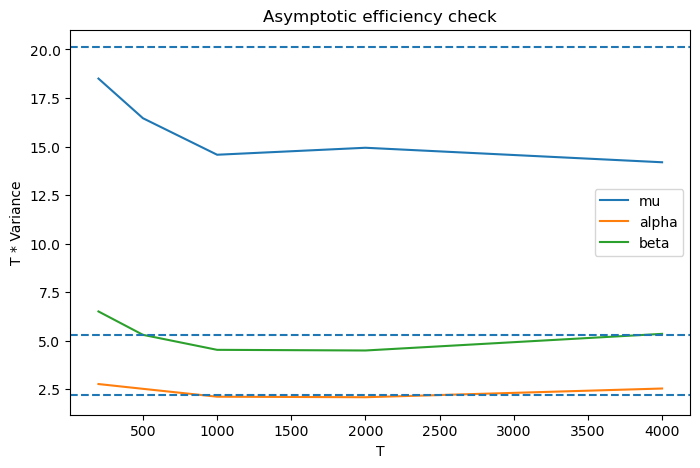

In [28]:
plt.figure(figsize=(8,5))

plt.plot(T_values,var_mu,label="mu")
plt.plot(T_values,var_alpha,label="alpha")
plt.plot(T_values,var_beta,label="beta")

plt.axhline(cramer_rao[0,0],linestyle="--")
plt.axhline(cramer_rao[1,1],linestyle="--")
plt.axhline(cramer_rao[2,2],linestyle="--")

plt.xlabel("T")
plt.ylabel("T * Variance")
plt.title("Asymptotic efficiency check")

plt.legend()
plt.show()